<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
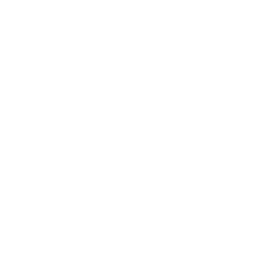
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnóstico de Perturbação em Reator Químico</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identificar as variáveis que causam a excedência do T² do reator durante o evento de perturbação &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Um reator de tanque agitado contínuo (CSTR) sofreu uma perturbação
térmica quando seu suprimento de refrigerante se degradou. Em operação
normal, a vazão de refrigerante, a temperatura do reator e a
temperatura da camisa se movem juntas ao longo de um único eixo de
carga do processo. Construímos um modelo MVP de três componentes com
100 observações em operação normal, e então avaliamos 100 observações
de perturbação contra ele com `PROC MVPDIAGNOSE`. Decompor a
estatística T-quadrado de Hotelling em contribuições por variável
isola o trio de acoplamento térmico — `jacket_temp`, `coolant_flow` e
`reactor_temp` — como as variáveis que causam a excedência, apontando
a operação diretamente para o subsistema de refrigerante.

## Fontes de Dados

| Dataset | Papel | Observações |
|---|---|---|
| `reactor_normal` | Dados de treinamento em operação normal para o modelo MVP | 100 |
| `reactor_upset` | Observações do evento de perturbação avaliadas contra o modelo | 100 |

As seis variáveis medidas são `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) e `pressure` (bar).
Ambos os datasets são simulados a partir de uma mesma *carga de
processo* latente compartilhada, de modo que os dados normais carregam
a mesma estrutura de correlação que um CSTR real exibe; a perturbação
injeta uma perda de suprimento de refrigerante que rompe essa
estrutura.

## Etapa 1 — Treinar o modelo MVP de operação normal

A operação normal é governada por uma carga de processo latente: uma
carga maior puxa a vazão de refrigerante para baixo enquanto empurra
as temperaturas do reator e da camisa para cima. `PROC MVPMODEL`
extrai três componentes principais das 100 observações normais e as
persiste com `OUTMODEL=` para que a etapa de diagnóstico possa avaliar
novos dados contra a mesma referência.

In [1]:
DADOS reactor_normal;
  CHAMAR streaminit(7);
  FAZER t = 1 ATÉ 100;
    load = rand('normal', 0, 1);                 /* carga latente do processo */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    SAÍDA;
  FIM;
EXECUTAR;

PROCEDIMENTO mvpmodel DADOS=reactor_normal outmodel=reactor_model;
  VARIÁVEL reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
EXECUTAR;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Etapa 2 — Avaliar o evento de perturbação e decompor T-quadrado

A perturbação reduz a vazão de refrigerante em cerca de 12 L/min
enquanto as temperaturas do reator e da camisa sobem — o acoplamento
normal entre refrigerante e temperatura é rompido. `PROC MVPDIAGNOSE`
avalia cada observação de perturbação contra o modelo de referência,
gravando os escores e resíduos padronizados em `OUT=` e as
contribuições de T-quadrado por variável em `OUTCONTRIB=`. Toda
observação fica muito além do limite de controle, confirmando uma
excursão multivariada sustentada em vez de ruído isolado.

In [2]:
DADOS reactor_upset;
  CHAMAR streaminit(101);
  FAZER t = 1 ATÉ 100;
    load = rand('normal', 0, 1);
    /* Bomba de refrigerante se degrada: vazão cai, temperaturas disparam */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    SAÍDA;
  FIM;
EXECUTAR;

PROCEDIMENTO mvpdiagnose DADOS=reactor_upset MODELO=reactor_model
                 out=reactor_scores;
  VARIÁVEL reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
EXECUTAR;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Etapa 3 — Classificar as contribuições médias

`OUTCONTRIB=` grava uma linha por observação avaliada com uma coluna
`<variável>_CONTRIB` para cada variável de processo. Calcular a média
dessas colunas dá a contribuição média de cada variável para a
perturbação; uma transposição remodela o resumo de uma linha em uma
tabela organizada de variável/valor que classifica os fatores da
falha.

In [3]:
PROCEDIMENTO MÉDIAS DADOS=reactor_contrib mean NOPRINT;
  VARIÁVEL reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  SAÍDA out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
EXECUTAR;

PROCEDIMENTO TRANSPOSE DADOS=contrib_means out=contrib_long name=metric;
  VARIÁVEL mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
EXECUTAR;

/* Atribuir nomes de variáveis legíveis e o valor de contribuição média */
DADOS contrib_ranked;
  DEFINIR contrib_long;
  COMPRIMENTO variable $24;
  SE      metric = 'mc_reactor_temp' ENTÃO variable = 'Temp. Reator';
  SENÃO SE metric = 'mc_coolant_flow' ENTÃO variable = 'Vazão Refrig.';
  SENÃO SE metric = 'mc_jacket_temp'  ENTÃO variable = 'Temp. Camisa';
  SENÃO SE metric = 'mc_feed_conc'    ENTÃO variable = 'Conc. Alimentação';
  SENÃO SE metric = 'mc_pressure'     ENTÃO variable = 'Pressão';
  mean_contrib = col1;
  MANTER variable mean_contrib;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=contrib_ranked;
  POR DECRESCENTE mean_contrib;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=contrib_ranked noobs;
  VARIÁVEL variable mean_contrib;
  RÓTULO variable     = 'Variável de Processo'
        mean_contrib = 'Contribuição Média de T²';
EXECUTAR;



 Variável de Processo      Contribuição Média de T²
---------------------  ----------------------------
Temp. Camisa                          4177.66720283
Vazão Refrig.                         2882.19501987
Temp. Reator                          1602.04200377
Pressão                                280.73140863
Conc. Alimentação                       61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/809f2888-ae15-4ef6-a551-19a6214c395a/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Etapa 4 — Gráfico de contribuição

O gráfico de contribuição torna o diagnóstico imediato: o trio
termicamente acoplado — `jacket_temp`, `coolant_flow` e
`reactor_temp` — ofusca `feed_conc` e `pressure`, que quase não
aparecem. As três barras dominantes são exatamente as variáveis
ligadas pelo laço de refrigerante, então a falha é inequivocamente
térmica, não um problema de alimentação ou de pressão.


NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


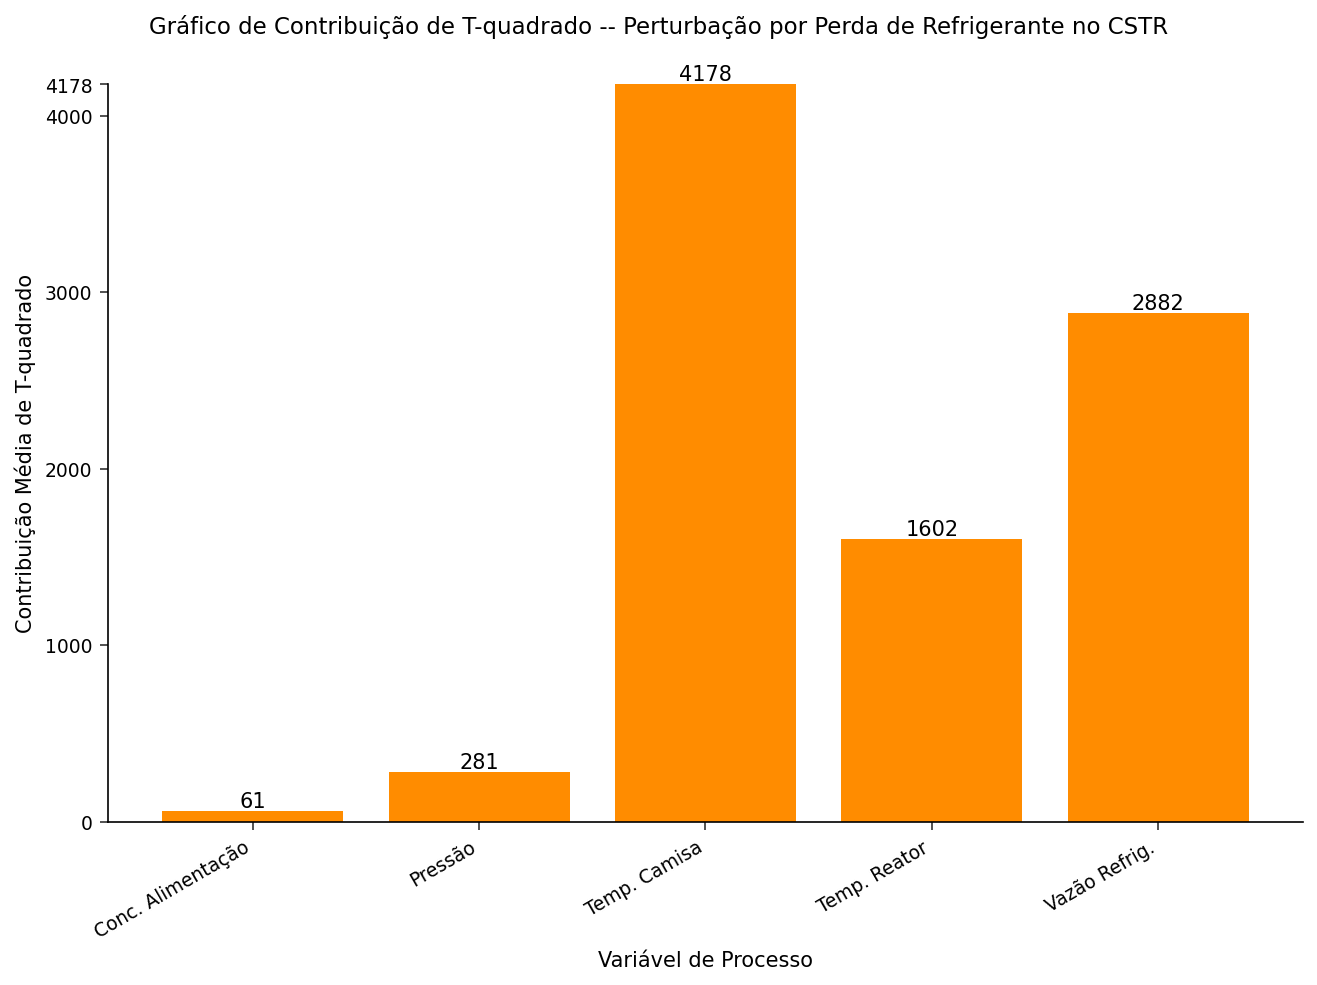

In [4]:
PROCEDIMENTO SGPLOT DADOS=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS RÓTULO='Variável de Processo';
  YAXIS RÓTULO='Contribuição Média de T-quadrado';
  TÍTULO 'Gráfico de Contribuição de T-quadrado -- Perturbação por Perda de Refrigerante no CSTR';
EXECUTAR;


## Etapa 5 — Linha do tempo de controle de T-quadrado

Plotar o T-quadrado de cada observação em relação ao limite de
controle do modelo mostra que a excursão é contínua: toda observação
de perturbação fica ordens de magnitude acima da linha de referência
do limite. Não há recuperação dentro da janela, consistente com uma
falha de hardware que persiste até que o subsistema de refrigerante
seja reparado.


NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


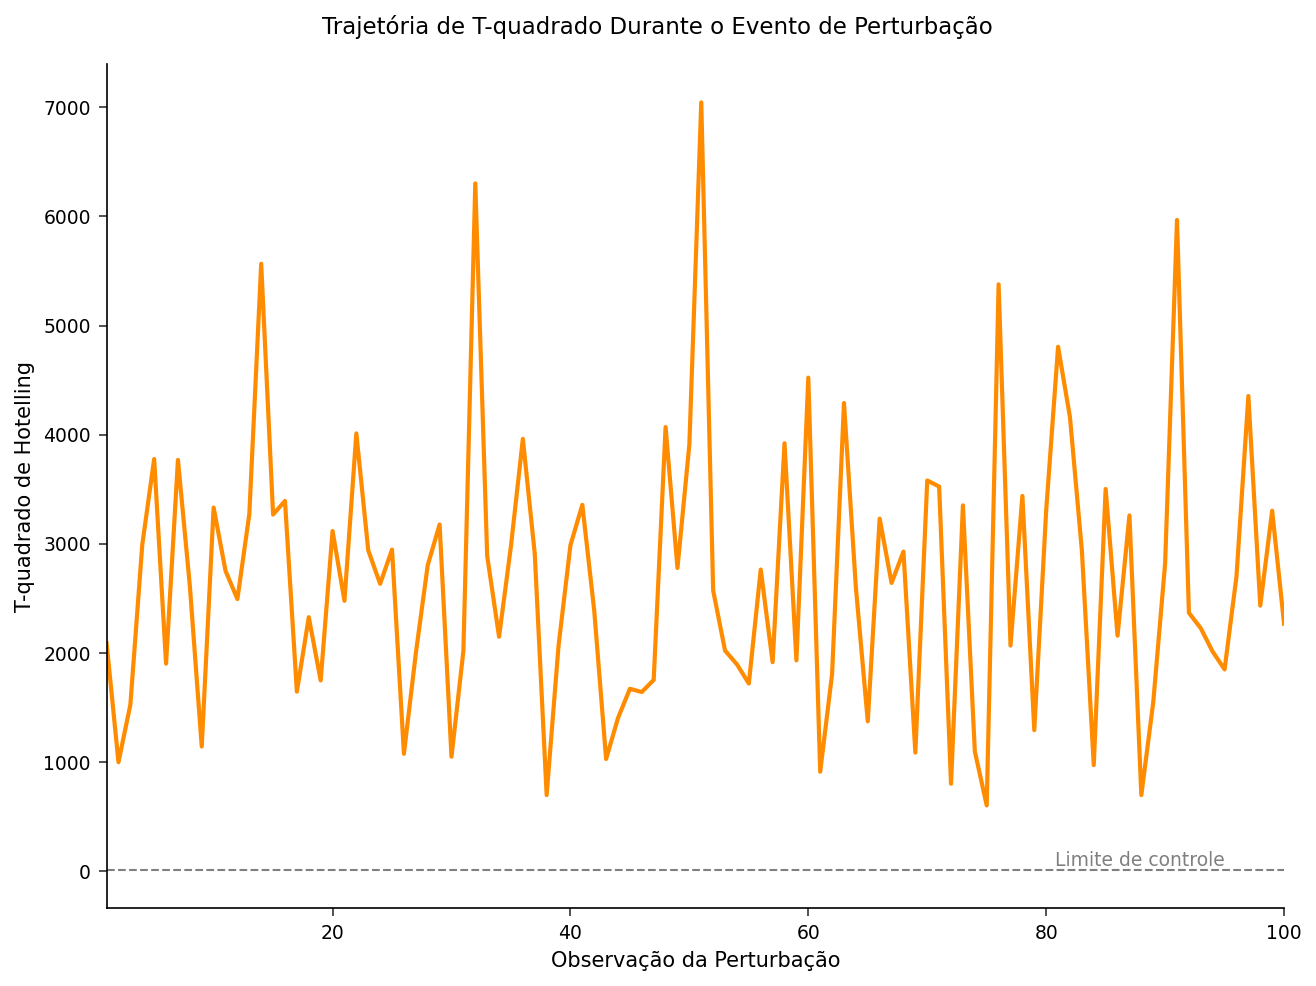

In [5]:
PROCEDIMENTO SGPLOT DADOS=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  RÓTULO='Limite de controle'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS RÓTULO='Observação da Perturbação';
  YAXIS RÓTULO='T-quadrado de Hotelling';
  TÍTULO 'Trajetória de T-quadrado Durante o Evento de Perturbação';
EXECUTAR;


## Conclusões e Ação Corretiva

- **Principais fatores**: `jacket_temp`, `coolant_flow` e
  `reactor_temp` juntas respondem por essencialmente todo o sinal de
  T-quadrado; suas contribuições médias são de duas a três ordens de
  magnitude acima de `feed_conc` e `pressure`.
- **Causa raiz**: uma perda de suprimento de refrigerante.
  `coolant_flow` é a única variável *manipulada* das três — as
  elevações de temperatura são consequências a jusante da perda de
  resfriamento, então a falha acionável é o subsistema de
  refrigerante.
- **Status de controle**: todas as 100 observações de perturbação
  ultrapassam o limite de T-quadrado, indicando uma excursão
  sustentada em vez de transitória.
- **Ação corretiva**: inspecionar e reconstruir a bomba de
  refrigerante; adicionar um transmissor redundante de vazão de
  refrigerante para que uma futura perda de suprimento seja detectada
  por alarme univariado antes que se propague para o laço de
  temperatura.

## Exportar as contribuições classificadas

A tabela de contribuições classificadas é gravada em CSV para o
relatório pós-evento e painéis downstream.

In [6]:
PROCEDIMENTO EXPORT DADOS=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
EXECUTAR;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>